In [2]:
import plotnine as p9
import geopandas as gpd
import pandas as pd
from pathlib import Path

In [54]:
DATA_DIR = Path("../caiso_data")
CA_TIMEZONE = "US/Pacific"


In [73]:
data_mer = pd.read_parquet(DATA_DIR / Path("sgip_caiso_mer.parquet"))
data_fuelgen = pd.read_parquet(DATA_DIR / Path("eia_fuel_type_gen.parquet"))
data_demand = pd.read_parquet(DATA_DIR / Path("eia_dlap_demand.parquet"))

In [74]:
polygon_california = gpd.read_file(DATA_DIR / Path("california_polygon.gpkg"))
polygon_caiso = gpd.read_file(DATA_DIR / Path("caiso_polygon.gpkg"))
polygon_dlap = gpd.read_file(DATA_DIR / Path("dlap_polygons.gpkg"))

In [75]:
# Convert to California local time for interpretability
data_mer["datetime"] = data_mer["datetime"].dt.tz_convert(CA_TIMEZONE)
data_fuelgen["datetime"] = data_fuelgen["datetime"].dt.tz_convert(CA_TIMEZONE)
data_demand["datetime"] = data_demand["datetime"].dt.tz_convert(CA_TIMEZONE)

### data_mer

In [ ]:
# deseasonalize MER data for each DLAP
season_map = {
    1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter'
}

data_mer_deseason = data_mer.copy()
data_mer_deseason["season"] = data_mer_deseason["datetime"].dt.month.map(season_map)

data_mer_seasonal_mean = data_mer_deseason.groupby(["season", "dlap"]).mean()
data_mer_seasonal_mean = data_mer_seasonal_mean.drop(columns=["datetime"])

data_mer_deseason["deseason_mer_kgCO2kWh"] = data_mer_deseason.set_index(
    ["season", "dlap"]
).sub(
    other = data_mer_seasonal_mean
).reset_index()["mer_kgCO2kWh"]

data_mer_deseason = data_mer_deseason[["dlap", "datetime", "season", "deseason_mer_kgCO2kWh"]]

data_mer_deseason.head()

,dlap,datetime,season,deseason_mer_kgCO2kWh
0,PGE,2024-12-31 16:00:00-08:00,winter,0.024274
1,PGE,2024-12-31 16:05:00-08:00,winter,0.107808
2,PGE,2024-12-31 16:10:00-08:00,winter,0.119940
3,PGE,2024-12-31 16:15:00-08:00,winter,0.093814
4,PGE,2024-12-31 16:20:00-08:00,winter,0.107686


In [ ]:
# Get hourly mean MER for each DLAP
data_mer_temp = data_mer.copy()
data_mer_temp["hour_of_day"] = data_mer_temp["datetime"].dt.hour

data_mer_hourly_mean = data_mer_temp.groupby(["hour_of_day", "dlap"]).mean()
data_mer_hourly_mean = data_mer_hourly_mean[["mer_kgCO2kWh"]].reset_index()
data_mer_hourly_mean.head()

,hour_of_day,dlap,mer_kgCO2kWh
0,0,PGE,0.470809
1,0,SCE,0.441609
2,0,SDGE,0.449067
3,1,PGE,0.447415
4,1,SCE,0.419402


In [ ]:
# Get deseasonalized hourly mean MER for each DLAP
data_mer_temp = data_mer_deseason.copy()
data_mer_temp["hour_of_day"] = data_mer_temp["datetime"].dt.hour

data_mer_deseason_hourly_mean = data_mer_temp.groupby(["season", "hour_of_day", "dlap"]).mean()
data_mer_deseason_hourly_mean = data_mer_deseason_hourly_mean[["deseason_mer_kgCO2kWh"]].reset_index()
data_mer_deseason_hourly_mean.head()

,season,hour_of_day,dlap,deseason_mer_kgCO2kWh
0,autumn,0,PGE,0.062502
1,autumn,0,SCE,-0.075696
2,autumn,0,SDGE,0.052116
3,autumn,1,PGE,0.082106
4,autumn,1,SCE,-0.138804


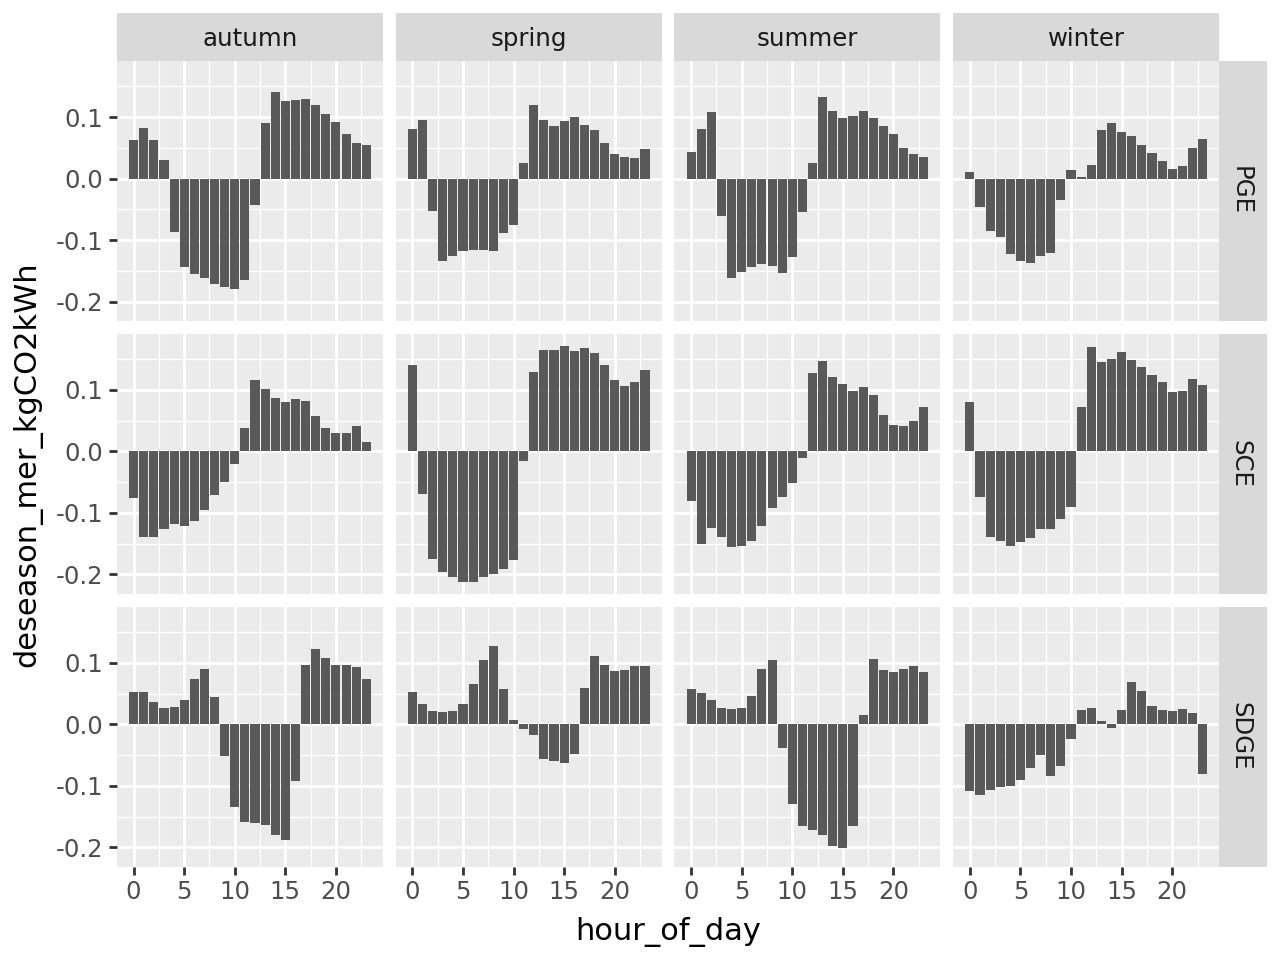

In [ ]:
(
p9.ggplot(data_mer_deseason_hourly_mean, mapping=p9.aes("hour_of_day", "deseason_mer_kgCO2kWh")) 
+ p9.geom_col()
+ p9.facet_grid(rows="dlap", cols="season")
)

## data_fuelgen

In [ ]:
# deseasonalize fuel generation data for each fuel type
season_map = {
    1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter'
}

data_fuelgen_deseason = data_fuelgen.copy()
data_fuelgen_deseason["season"] = data_fuelgen_deseason["datetime"].dt.month.map(season_map)

data_fuelgen_seasonal_mean = data_fuelgen_deseason.groupby(["season", "fuel_type"]).mean()
data_fuelgen_seasonal_mean = data_fuelgen_seasonal_mean.drop(columns=["datetime"])

data_fuelgen_deseason["deseason_generation_MWh"] = data_fuelgen_deseason.set_index(["season", "fuel_type"]).sub(
    data_fuelgen_seasonal_mean
).reset_index()[["generation_MWh"]]

data_fuelgen_deseason.head(10)


,datetime,fuel_type,generation_MWh,season,deseason_generation_MWh
0,2024-12-31 16:00:00-08:00,coal,-1,winter,0.0
1,2024-12-31 16:00:00-08:00,natural gas,8944,winter,0.0
2,2024-12-31 16:00:00-08:00,nuclear,2269,winter,0.0
3,2024-12-31 16:00:00-08:00,petroleum,46,winter,0.0
4,2024-12-31 16:00:00-08:00,other,-3968,winter,0.0
5,2024-12-31 16:00:00-08:00,solar,11648,winter,0.0
6,2024-12-31 16:00:00-08:00,hydro,1399,winter,0.0
7,2024-12-31 16:00:00-08:00,wind,328,winter,0.0
8,2024-12-31 17:00:00-08:00,wind,347,winter,0.0
9,2024-12-31 17:00:00-08:00,hydro,1699,winter,0.0


In [153]:
# Get the mean generated electricity per hour grouped by season and fuel type
season_map = {
    1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter'
}

data_fuelgen_temp = data_fuelgen.copy()
data_fuelgen_temp["hour_of_day"] = data_fuelgen_temp["datetime"].dt.hour
data_fuelgen_temp["season"] = data_fuelgen_temp["datetime"].dt.month.map(season_map)

data_fuelgen_seasonal_hourly_mean = data_fuelgen_temp.groupby(by=["season", "hour_of_day", "fuel_type"]).mean()
data_fuelgen_seasonal_hourly_mean = data_fuelgen_seasonal_hourly_mean["generation_MWh"].reset_index()

data_fuelgen_seasonal_hourly_mean.head()

,season,hour_of_day,fuel_type,generation_MWh
0,autumn,0,coal,0.000000
1,autumn,0,hydro,2912.604396
2,autumn,0,natural gas,10363.153846
3,autumn,0,nuclear,1859.274725
4,autumn,0,other,2150.725275


In [173]:
data_fuelgen["fuel_type"].unique()

<ArrowStringArray>
[       'coal', 'natural gas',     'nuclear',   'petroleum',       'other',
       'solar',       'hydro',        'wind',  'geothermal']
Length: 9, dtype: str

In [182]:
# Get proportion of electricity generated using source_of_interest (soi) per hour grouped by season

source_of_interest = "solar"

data_fuelgen_seasonal_hourly_prop = data_fuelgen_seasonal_hourly_mean.copy()

data_fuelgen_seasonal_hourly_total = data_fuelgen_seasonal_hourly_prop.groupby(by=["season", "hour_of_day"]).sum(numeric_only=True)
data_fuelgen_seasonal_hourly_total = data_fuelgen_seasonal_hourly_total.reset_index()
data_fuelgen_seasonal_hourly_total = data_fuelgen_seasonal_hourly_total.set_index(["season", "hour_of_day"])

data_fuelgen_seasonal_hourly_soi = data_fuelgen_seasonal_hourly_prop.where((data_fuelgen_seasonal_hourly_prop["fuel_type"] == source_of_interest)).dropna(ignore_index=True)
data_fuelgen_seasonal_hourly_soi = data_fuelgen_seasonal_hourly_soi.drop(columns=["fuel_type"])
data_fuelgen_seasonal_hourly_soi = data_fuelgen_seasonal_hourly_soi.set_index(["season", "hour_of_day"])

data_fuelgen_seasonal_hourly_prop = data_fuelgen_seasonal_hourly_soi.div(data_fuelgen_seasonal_hourly_total).reset_index()
data_fuelgen_seasonal_hourly_prop["generation_MWh"] = data_fuelgen_seasonal_hourly_prop["generation_MWh"].clip(lower = 0)
data_fuelgen_seasonal_hourly_prop = data_fuelgen_seasonal_hourly_prop.rename(columns={"generation_MWh" : "prop_soi_gen_MWh"})
data_fuelgen_seasonal_hourly_prop.head()

,season,hour_of_day,prop_soi_gen_MWh
0,autumn,0.0,0.0
1,autumn,1.0,0.0
2,autumn,2.0,0.0
3,autumn,3.0,0.0
4,autumn,4.0,0.0


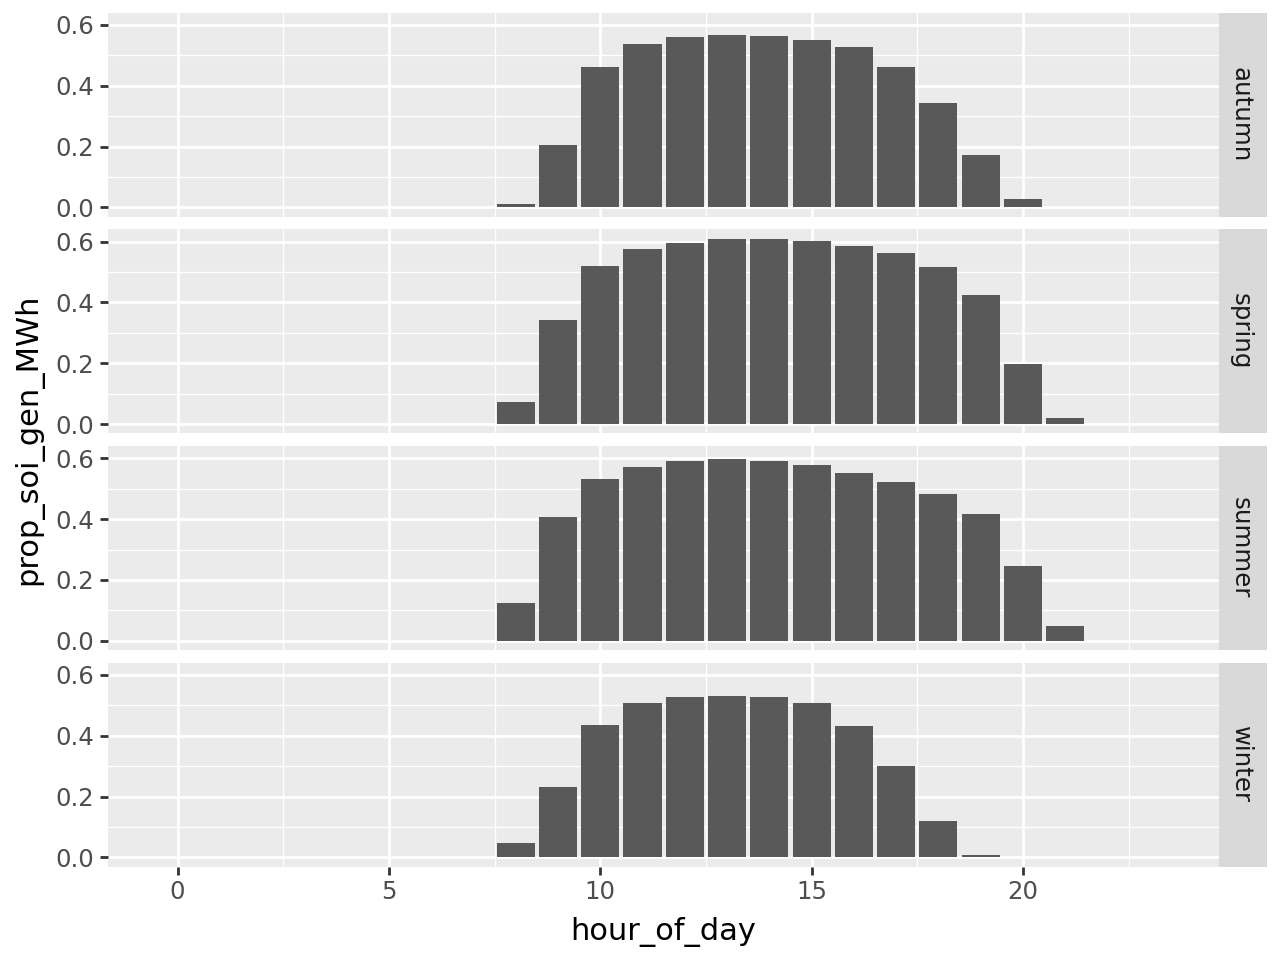

In [183]:
(
p9.ggplot(data_fuelgen_seasonal_hourly_prop, mapping=p9.aes("hour_of_day", "prop_soi_gen_MWh")) 
+ p9.geom_col()
+ p9.facet_grid(rows="season")
)